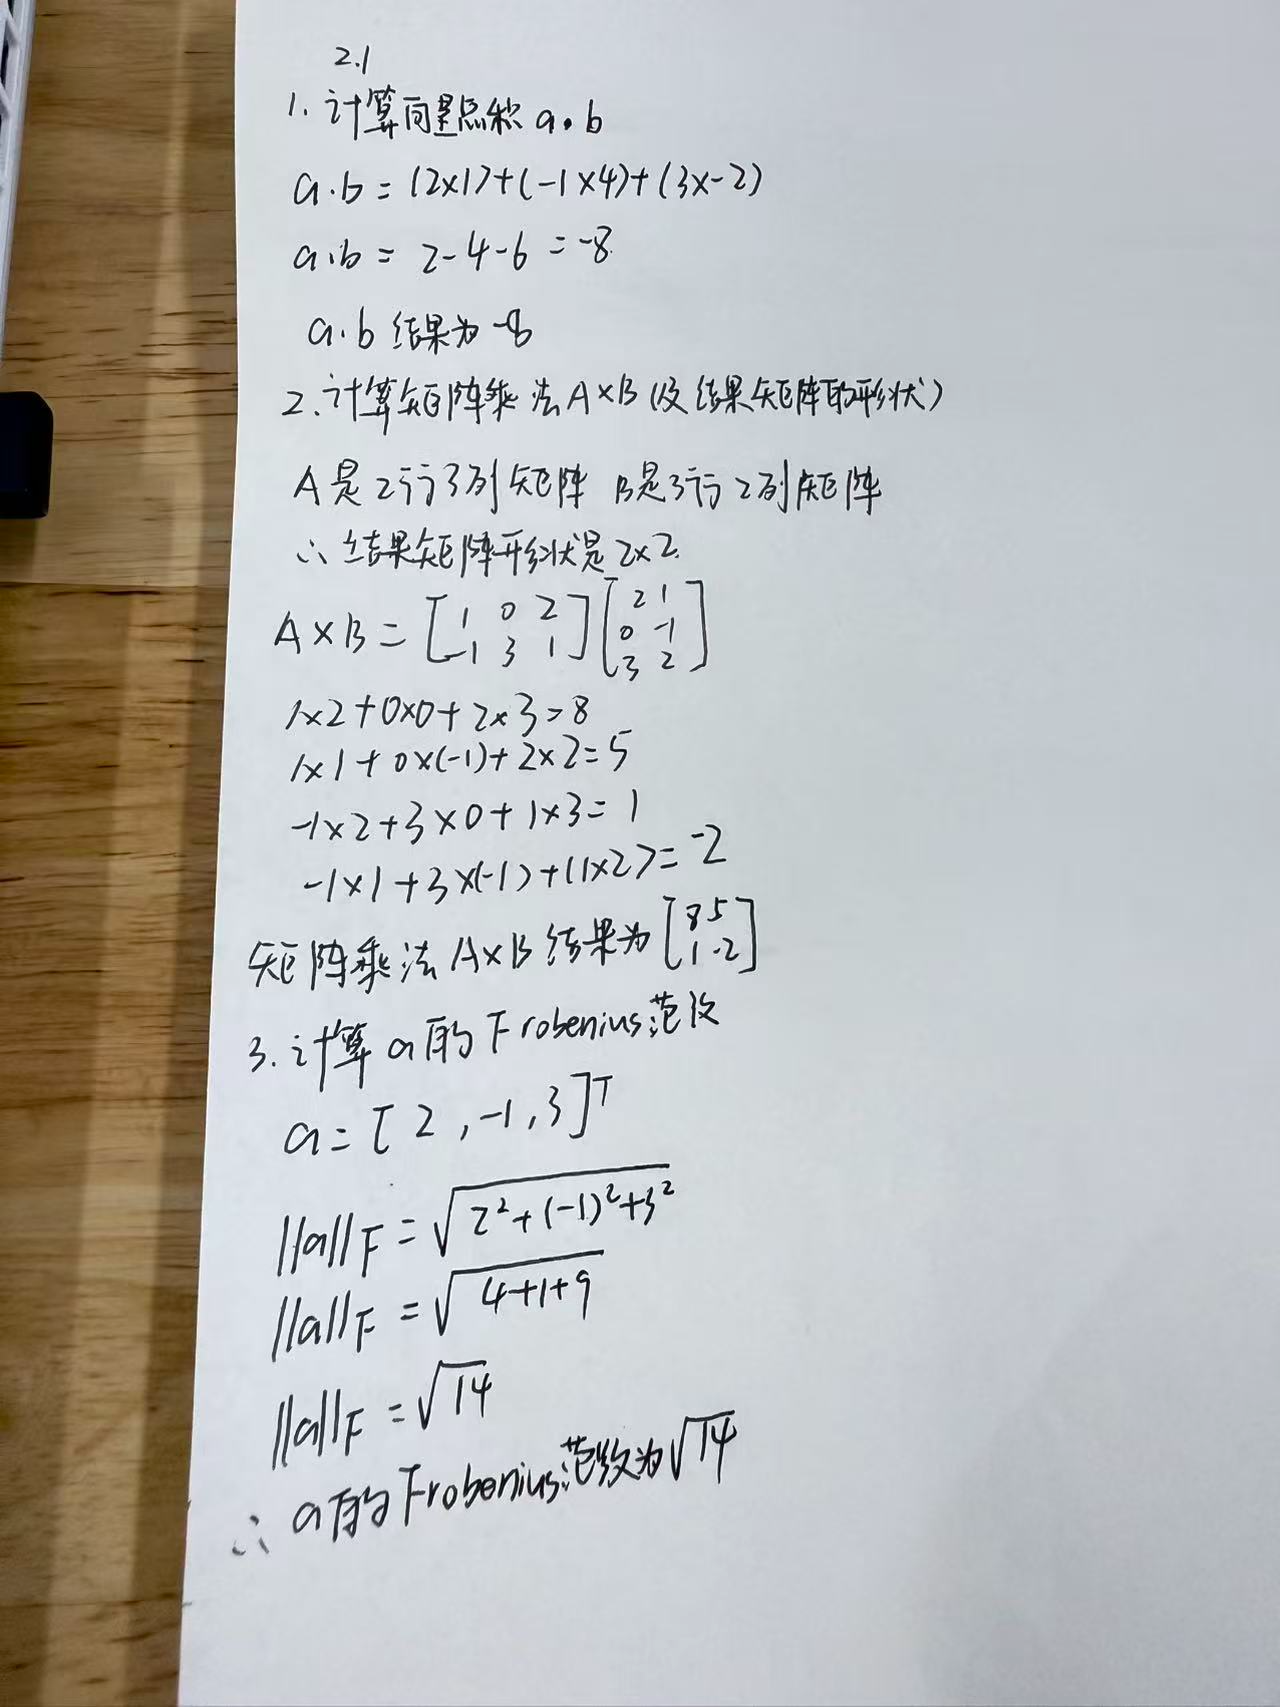

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import torch

# 设置随机种子保证可重复性
np.random.seed(42)
torch.manual_seed(42)

print("="*60)
print("2.2 NumPy编程题")
print("="*60)

# 1. 创建形状为3x4的随机矩阵X，元素服从标准正态分布
X = np.random.randn(3, 4)
print(f"1. 随机矩阵X (3x4):\n{X}\n")

# 2. 创建形状为4x2的全1矩阵Y
Y = np.ones((4, 2))
print(f"2. 全1矩阵Y (4x2):\n{Y}\n")

# 3. 计算矩阵乘法Z = X × Y
Z = X @ Y
print(f"3. 矩阵乘法Z = X × Y (3x2):\n{Z}\n")

# 4. 输出Z的第一行和第二列交叉处的元素，以及Z的第2行所有元素
print(f"4. Z的第一行第二列交叉处元素: {Z[0, 1]}")
print(f"   Z的第2行所有元素: {Z[1, :]}\n")

# 5. 计算Z的Frobenius范数
frobenius_norm = np.linalg.norm(Z, 'fro')
print(f"5. Z的Frobenius范数: {frobenius_norm:.6f}")

2.2 NumPy编程题
1. 随机矩阵X (3x4):
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

2. 全1矩阵Y (4x2):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

3. 矩阵乘法Z = X × Y (3x2):
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

4. Z的第一行第二列交叉处元素: 2.5291682463487657
   Z的第2行所有元素: [1.87835721 1.87835721]

5. Z的Frobenius范数: 4.616873


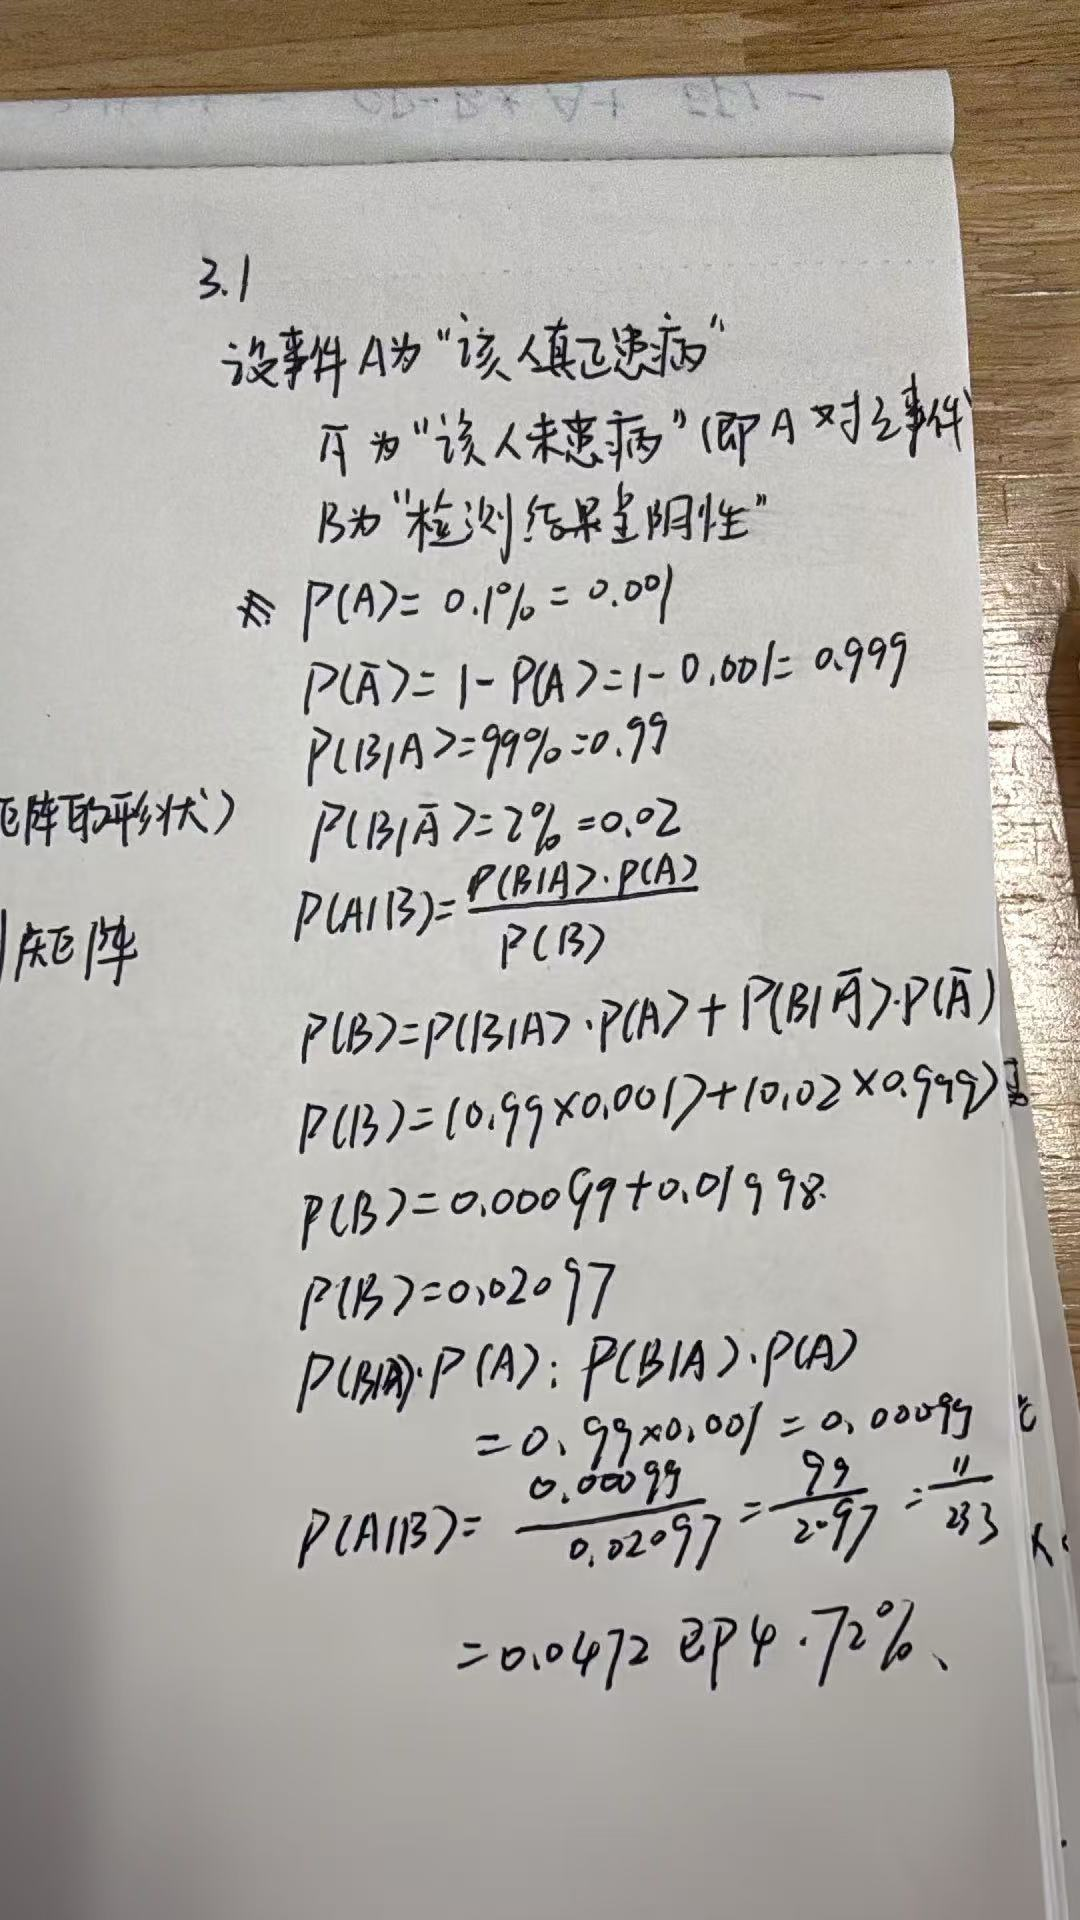


3.2 中心极限定理模拟


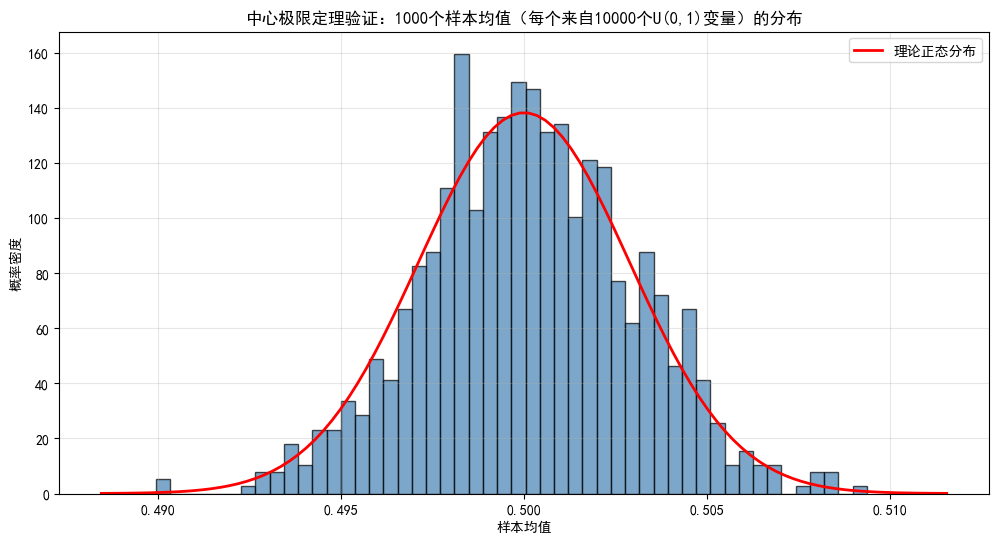

1. 生成了 1000 个样本均值，每个来自 10000 个U(0,1)随机变量
2. 实际均值: 0.500128 (理论: 0.5)
3. 实际方差: 0.00000819
   理论方差: 0.00000833
   相对误差: 1.6631%


In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print("\n" + "="*60)
print("3.2 中心极限定理模拟")
print("="*60)

# 参数设置
n = 10000  # 每个样本的随机变量个数
m = 1000   # 重复次数

# 生成m个均值
sample_means = []
for _ in range(m):
    # 生成n个U(0,1)均匀分布随机变量
    samples = np.random.uniform(0, 1, n)
    # 计算均值
    sample_means.append(np.mean(samples))

sample_means = np.array(sample_means)

# 理论：U(0,1)的均值为0.5，方差为1/12
# 均值的理论方差 = 方差/n = (1/12)/10000 = 1/120000 ≈ 8.333e-6
# 均值的理论标准差 = sqrt(1/120000) ≈ 0.00288675

# 绘制直方图
plt.figure(figsize=(12, 6))
plt.hist(sample_means, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')

# 叠加理论正态分布曲线
from scipy.stats import norm
mu_theory = 0.5
sigma_theory = np.sqrt(1/12 / n)  # 均值的理论标准差
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 100)
plt.plot(x, norm.pdf(x, mu_theory, sigma_theory), 'r-', linewidth=2, label='理论正态分布')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title(f'中心极限定理验证：{m}个样本均值（每个来自{n}个U(0,1)变量）的分布')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('clt_demo.png', dpi=150, bbox_inches='tight')
plt.show()

# 计算实际方差
actual_variance = np.var(sample_means)
theoretical_variance = 1/12 / n

print(f"1. 生成了 {m} 个样本均值，每个来自 {n} 个U(0,1)随机变量")
print(f"2. 实际均值: {np.mean(sample_means):.6f} (理论: {mu_theory})")
print(f"3. 实际方差: {actual_variance:.8f}")
print(f"   理论方差: {theoretical_variance:.8f}")
print(f"   相对误差: {abs(actual_variance - theoretical_variance)/theoretical_variance*100:.4f}%")

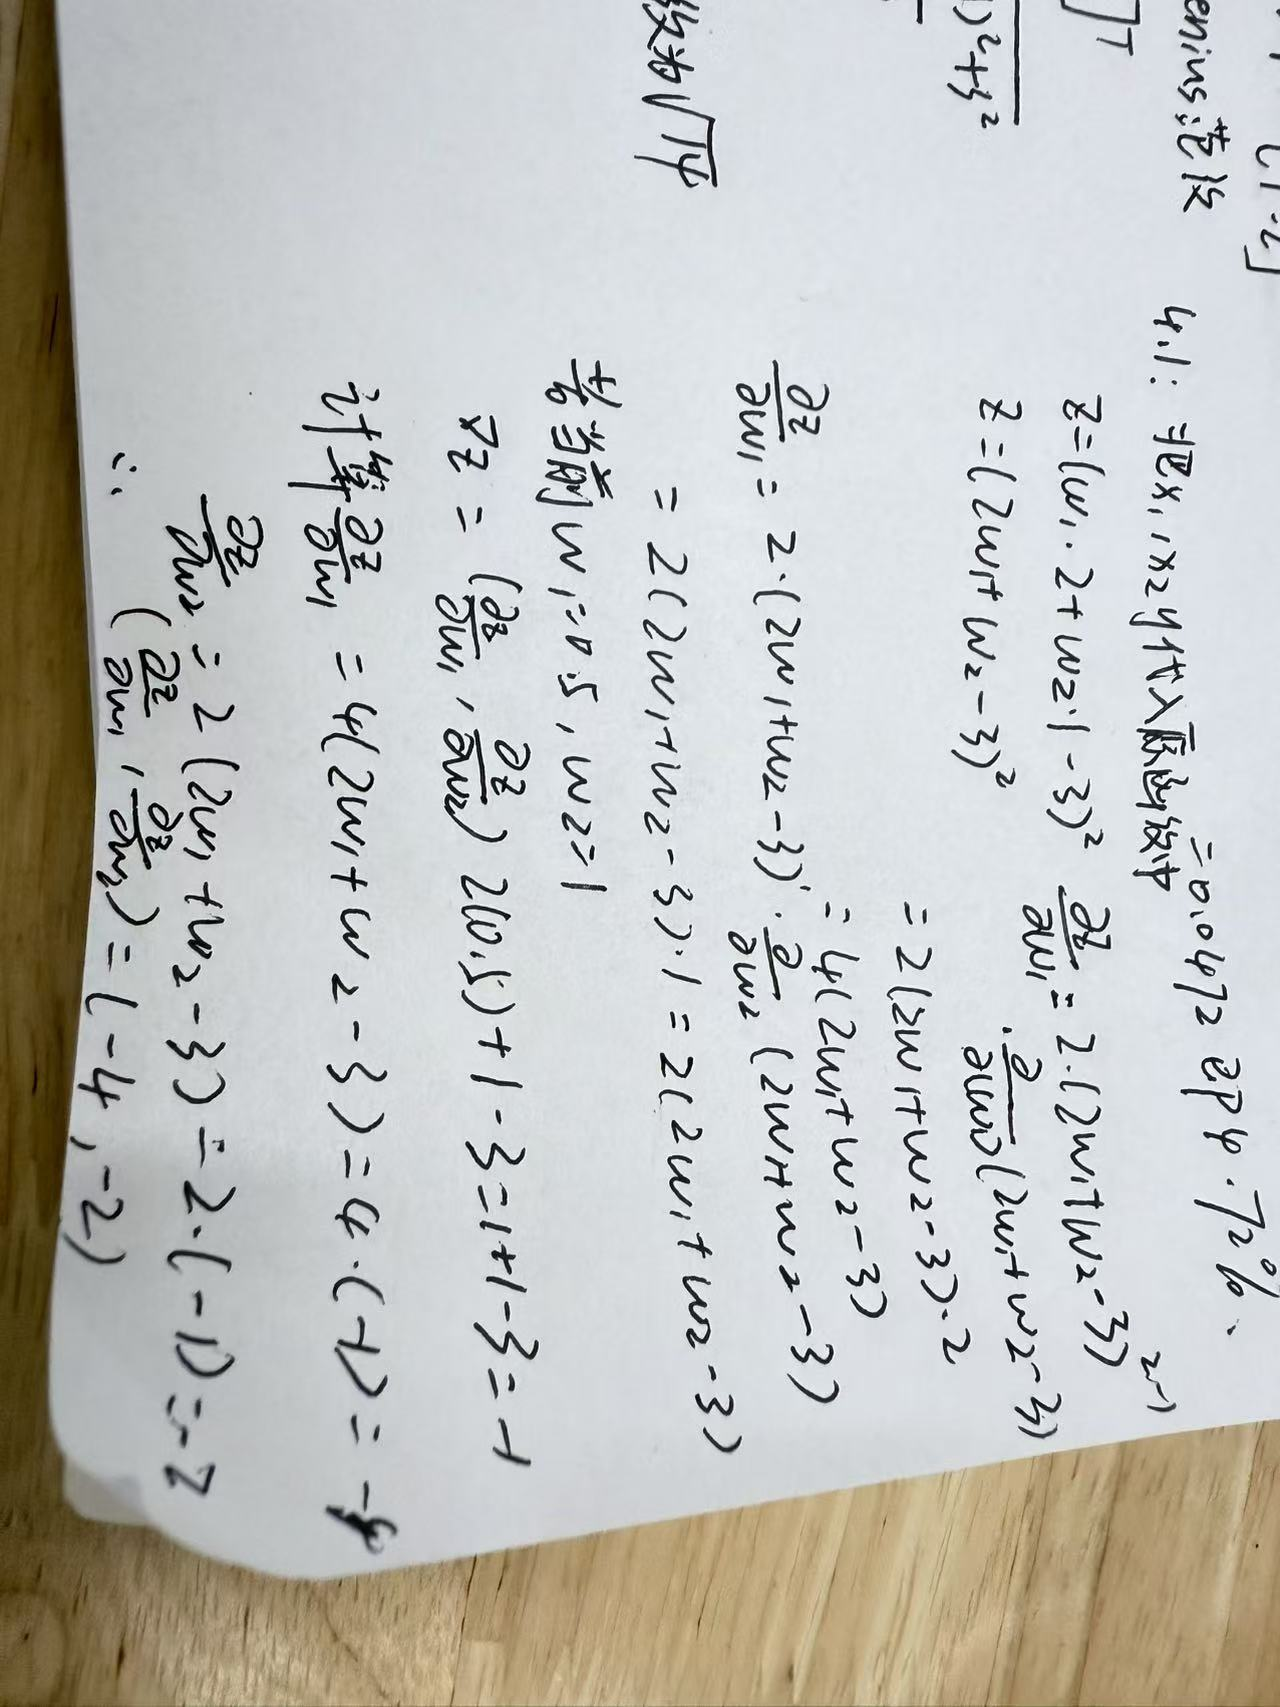

In [4]:
print("\n" + "="*60)
print("4.2 手动反向传播验证")
print("="*60)

# 给定参数
x = 2.0
w1 = 1.5
w2 = 0.5

# 前向计算
a = x * w1          # a = x * w1
b = a + w2          # b = a + w2
L = b ** 2          # L = b^2

print(f"前向计算结果:")
print(f"  x = {x}, w1 = {w1}, w2 = {w2}")
print(f"  a = x * w1 = {a}")
print(f"  b = a + w2 = {b}")
print(f"  L = b^2 = {L}")

# 手动计算梯度（链式法则）
# dL/db = 2b
dL_db = 2 * b

# db/da = 1, db/dw2 = 1
# da/dw1 = x

# 因此:
# dL/dw1 = dL/db * db/da * da/dw1 = 2b * 1 * x = 2b*x
# dL/dw2 = dL/db * db/dw2 = 2b * 1 = 2b

dL_dw1_manual = 2 * b * x
dL_dw2_manual = 2 * b

print(f"\n手动计算的梯度:")
print(f"  ∂L/∂w1 = 2*b*x = {dL_dw1_manual}")
print(f"  ∂L/∂w2 = 2*b = {dL_dw2_manual}")

# 使用PyTorch验证
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

L_t.backward()

print(f"\nPyTorch自动计算的梯度:")
print(f"  ∂L/∂w1 = {w1_t.grad.item():.6f}")
print(f"  ∂L/∂w2 = {w2_t.grad.item():.6f}")

# 验证一致性
print(f"\n验证结果:")
print(f"  ∂L/∂w1 一致: {abs(dL_dw1_manual - w1_t.grad.item()) < 1e-6}")
print(f"  ∂L/∂w2 一致: {abs(dL_dw2_manual - w2_t.grad.item()) < 1e-6}")


4.2 手动反向传播验证
前向计算结果:
  x = 2.0, w1 = 1.5, w2 = 0.5
  a = x * w1 = 3.0
  b = a + w2 = 3.5
  L = b^2 = 12.25

手动计算的梯度:
  ∂L/∂w1 = 2*b*x = 14.0
  ∂L/∂w2 = 2*b = 7.0

PyTorch自动计算的梯度:
  ∂L/∂w1 = 14.000000
  ∂L/∂w2 = 7.000000

验证结果:
  ∂L/∂w1 一致: True
  ∂L/∂w2 一致: True


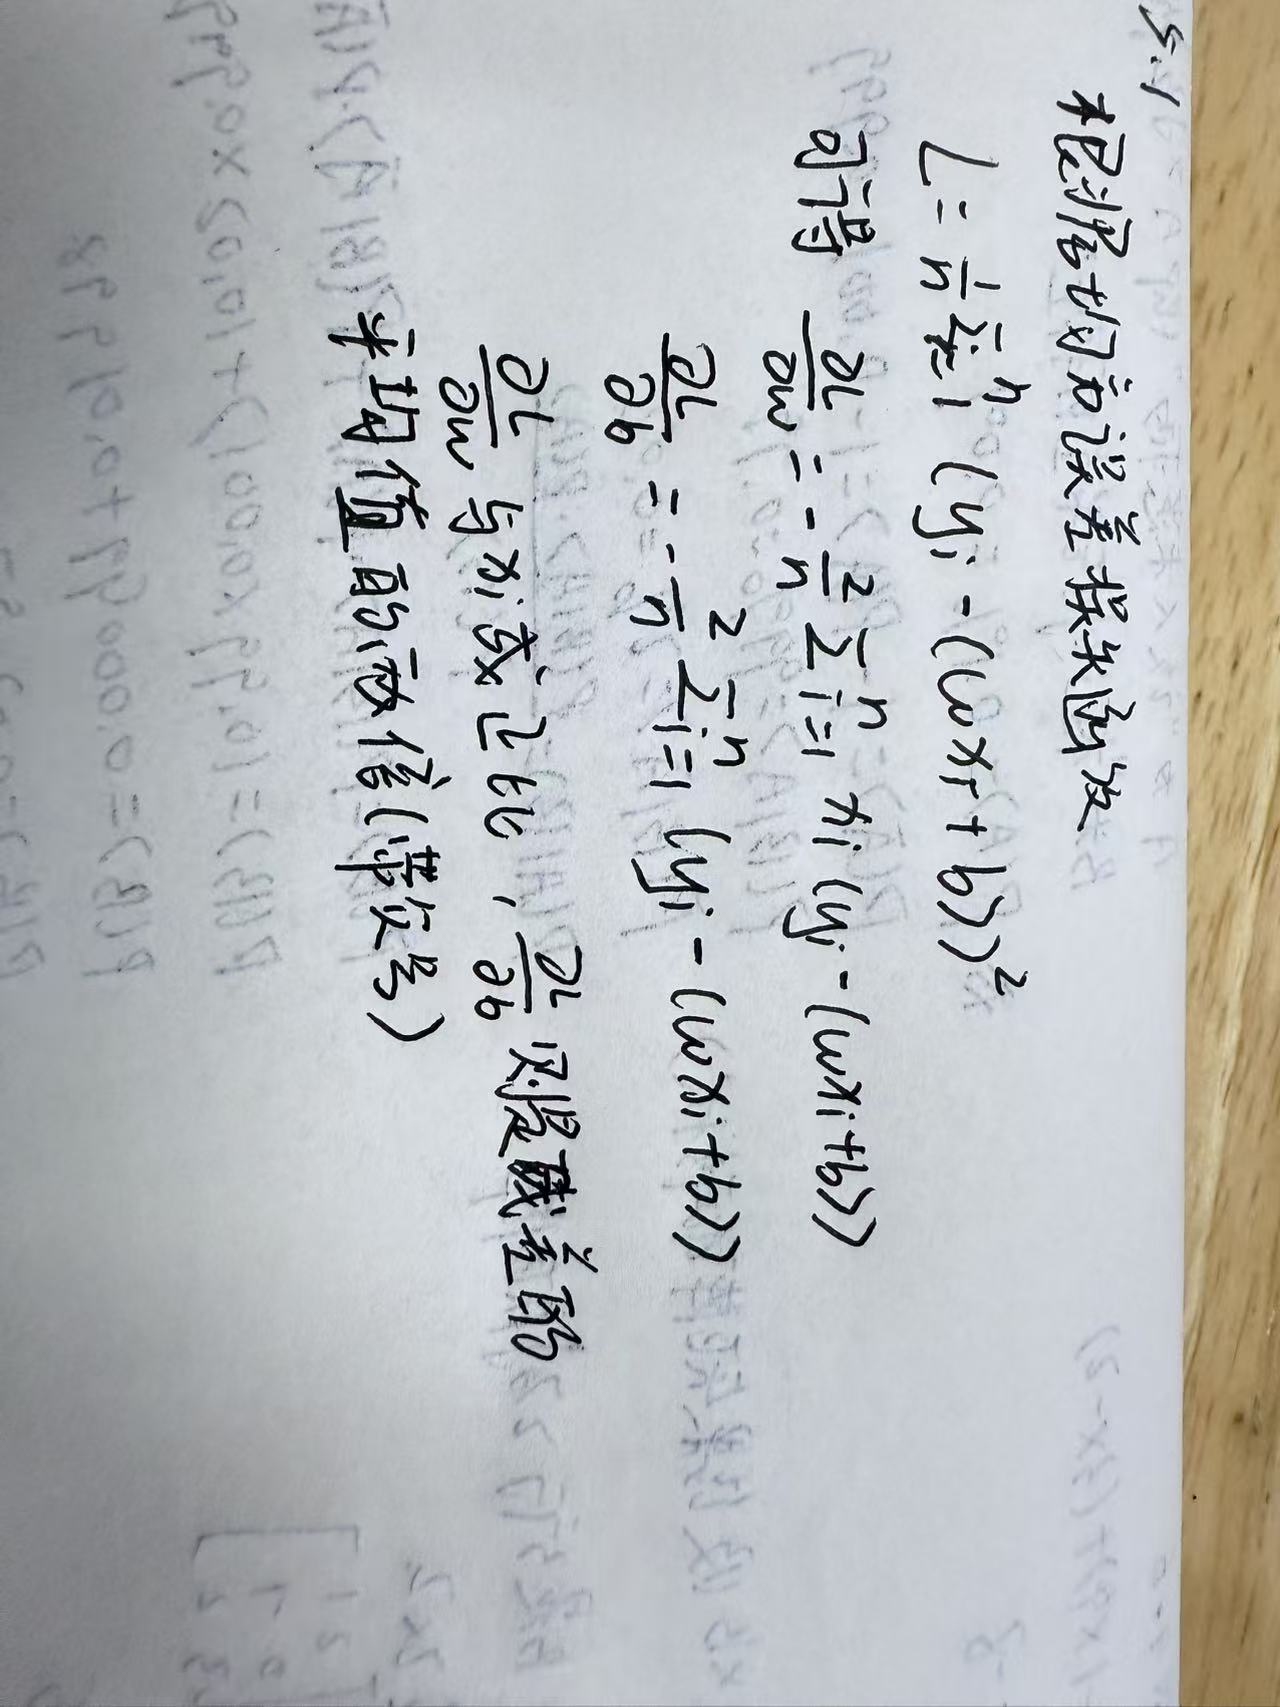


5.2 Softmax回归 - MNIST手写数字分类
训练集大小: 1437, 测试集大小: 360
特征维度: 64, 类别数: 10
Epoch 10/50, Loss: 0.457810
Epoch 20/50, Loss: 0.300698
Epoch 30/50, Loss: 0.240665
Epoch 40/50, Loss: 0.208045
Epoch 50/50, Loss: 0.186050

测试集准确率: 95.83%


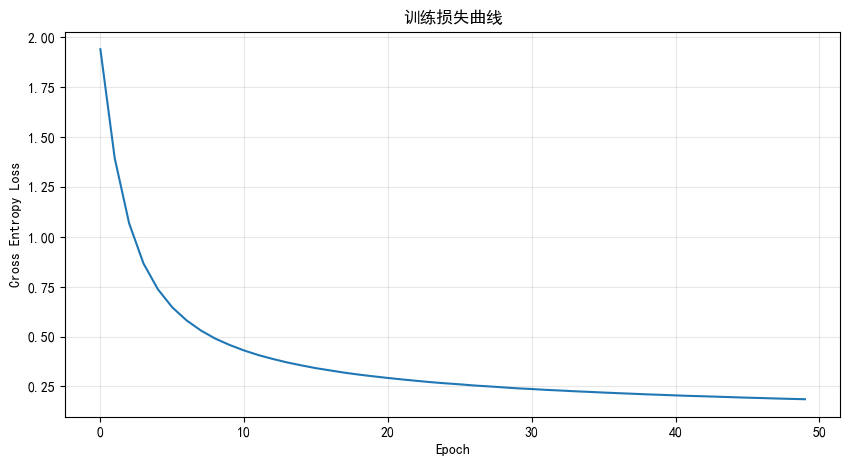

In [5]:
print("\n" + "="*60)
print("5.2 Softmax回归 - MNIST手写数字分类")
print("="*60)

# 加载数据
digits = load_digits()
X = digits.data  # (1797, 64) - 8x8图像展平
y = digits.target  # (1797,)

# 归一化特征
X = X / 16.0  # 像素值范围0-16，归一化到0-1

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot编码标签
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

n_classes = 10
n_features = X_train.shape[1]

print(f"训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")
print(f"特征维度: {n_features}, 类别数: {n_classes}")

# 初始化参数
np.random.seed(42)
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

def softmax(z):
    """Softmax函数，数值稳定版本"""
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    """交叉熵损失"""
    n = y_pred.shape[0]
    # 避免log(0)
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    loss = -np.sum(y_true * np.log(y_pred)) / n
    return loss

# 训练参数
batch_size = 32
learning_rate = 0.1
n_epochs = 50

# 训练循环
losses = []
for epoch in range(n_epochs):
    # 随机打乱数据
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0
    n_batches = 0
    
    # 小批量梯度下降
    for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        logits = X_batch @ W + b
        y_pred = softmax(logits)
        
        # 计算损失
        loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        n_batches += 1
        
        # 反向传播
        # 梯度: dL/dlogits = y_pred - y_true
        grad_logits = y_pred - y_batch
        
        # 参数梯度
        grad_W = (X_batch.T @ grad_logits) / batch_size
        grad_b = np.mean(grad_logits, axis=0, keepdims=True)
        
        # 更新参数
        W -= learning_rate * grad_W
        b -= learning_rate * grad_b
    
    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}")

# 测试
logits_test = X_test @ W + b
y_test_pred = softmax(logits_test)
y_test_pred_class = np.argmax(y_test_pred, axis=1)
accuracy = np.mean(y_test_pred_class == y_test)

print(f"\n测试集准确率: {accuracy*100:.2f}%")

# 绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.title('训练损失曲线')
plt.grid(alpha=0.3)
plt.savefig('softmax_loss.png', dpi=150, bbox_inches='tight')
plt.show()

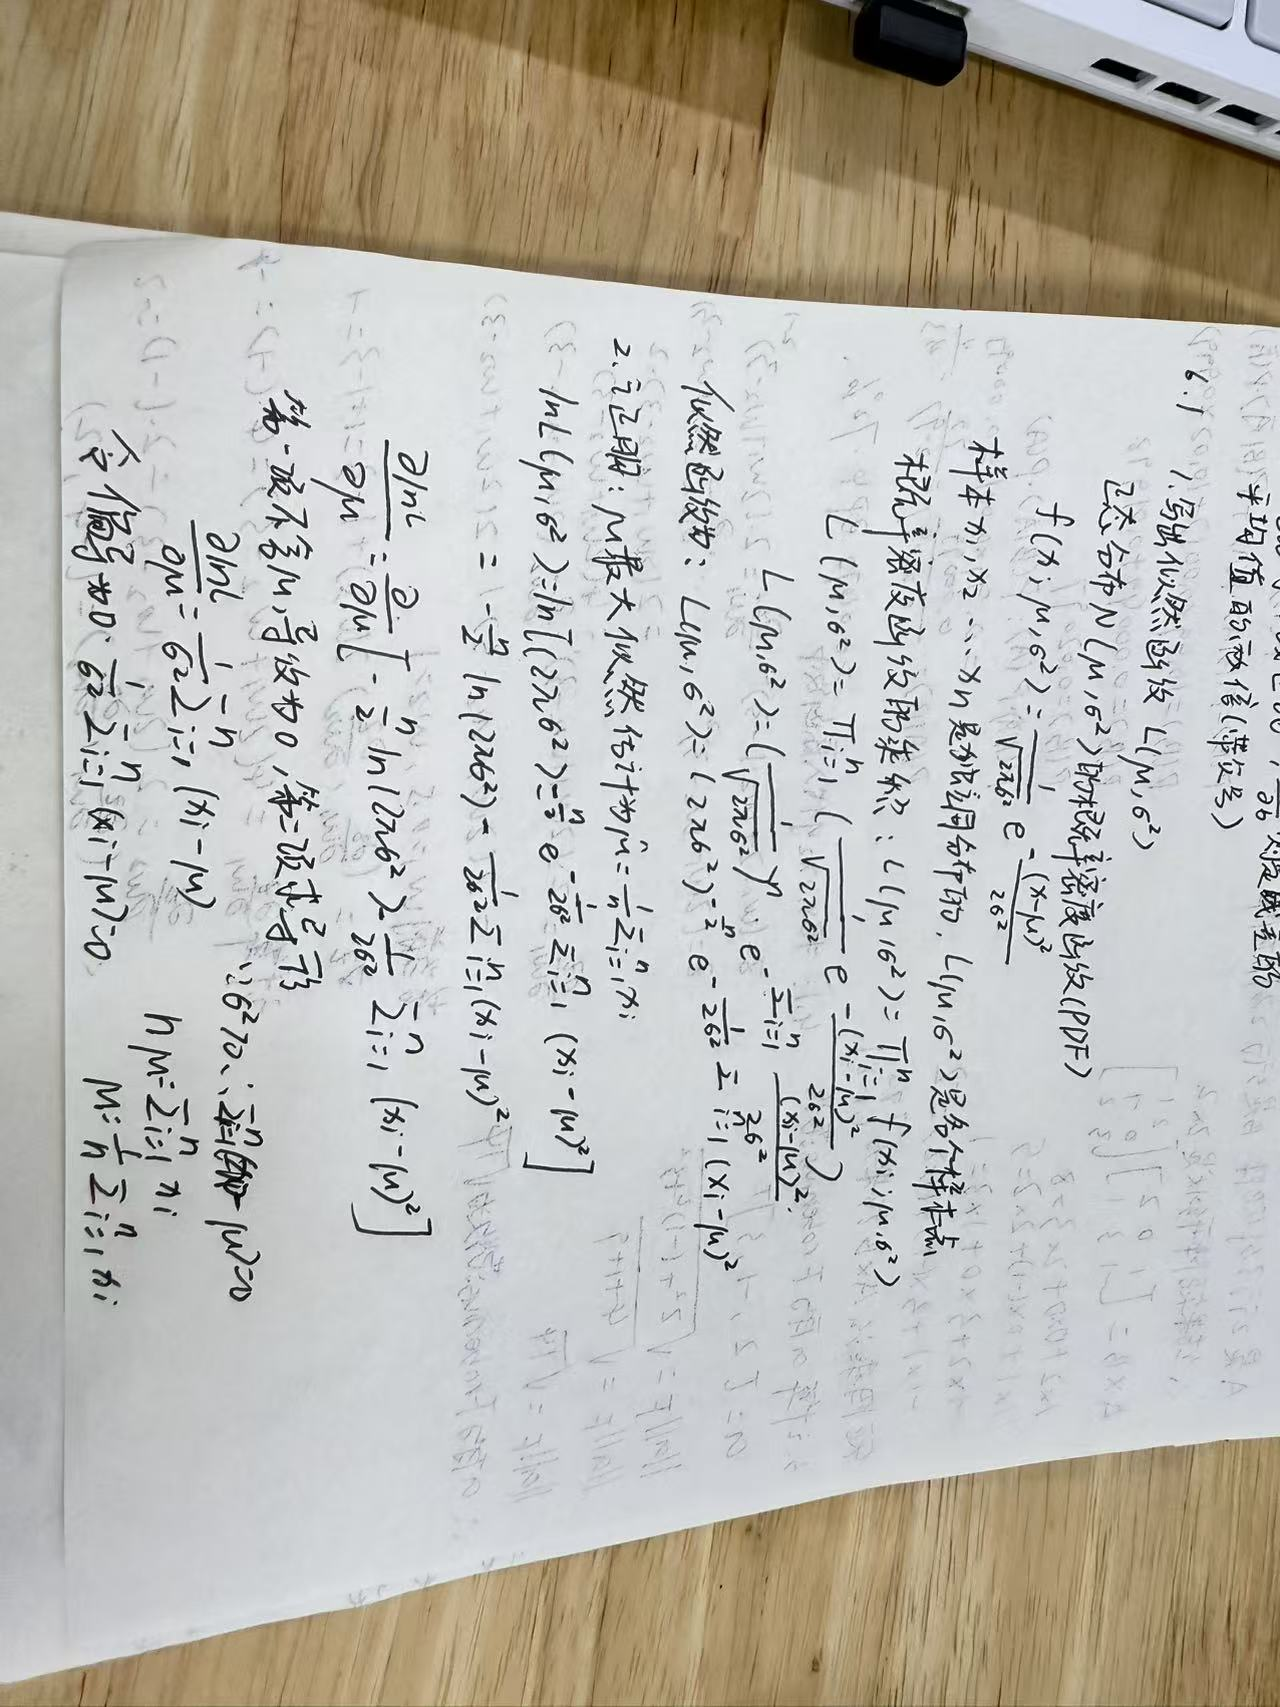

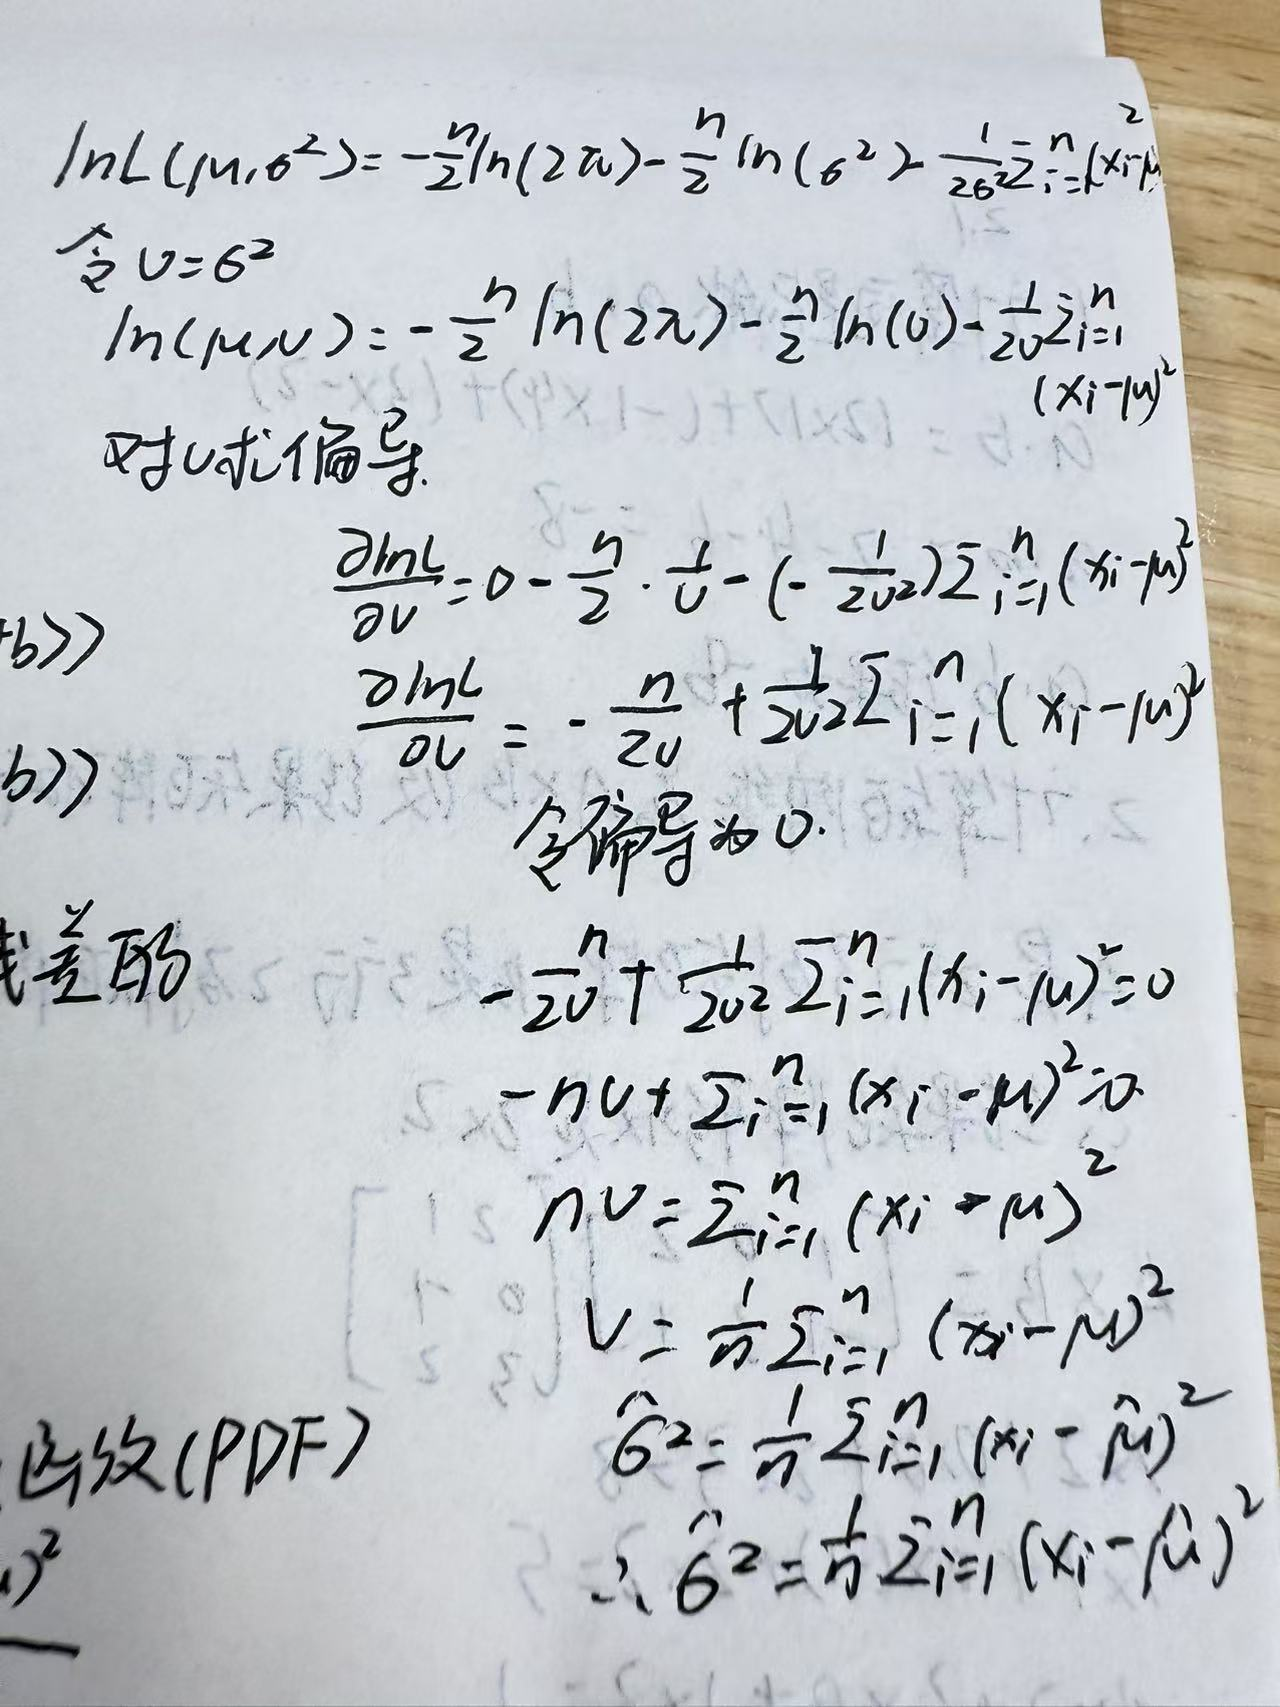


6.2 逻辑回归 - 二分类
训练集: 320样本, 测试集: 80样本
Iteration 200/1000, Loss: 0.253645
Iteration 400/1000, Loss: 0.170541
Iteration 600/1000, Loss: 0.134666
Iteration 800/1000, Loss: 0.114606
Iteration 1000/1000, Loss: 0.101721

学习到的参数: bias=-5.6712, w1=0.7129, w2=0.7946
测试集准确率: 100.00%


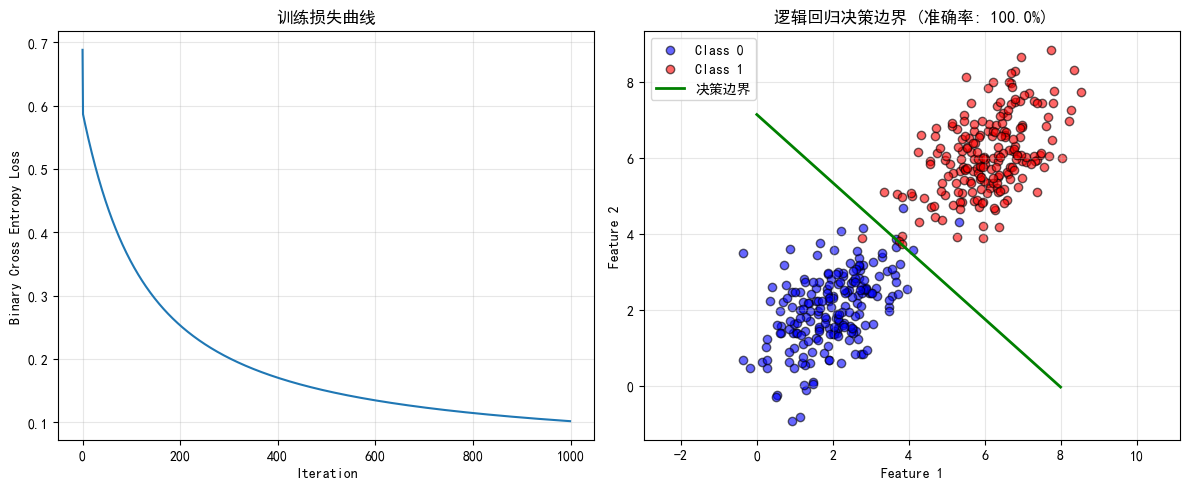

In [7]:
print("\n" + "="*60)
print("6.2 逻辑回归 - 二分类")
print("="*60)

# 生成线性可分数据
np.random.seed(42)
n_samples_per_class = 200

# 类别0: 均值为[2, 2]
mean0 = [2, 2]
cov = [[1, 0.5], [0.5, 1]]
class0 = np.random.multivariate_normal(mean0, cov, n_samples_per_class)

# 类别1: 均值为[6, 6]
mean1 = [6, 6]
class1 = np.random.multivariate_normal(mean1, cov, n_samples_per_class)

# 合并数据
X_binary = np.vstack([class0, class1])
y_binary = np.hstack([np.zeros(n_samples_per_class), np.ones(n_samples_per_class)])

# 划分训练集和测试集
indices = np.random.permutation(len(X_binary))
X_binary = X_binary[indices]
y_binary = y_binary[indices]

split_idx = int(0.8 * len(X_binary))
X_train_bin = X_binary[:split_idx]
X_test_bin = X_binary[split_idx:]
y_train_bin = y_binary[:split_idx]
y_test_bin = y_binary[split_idx:]

print(f"训练集: {X_train_bin.shape[0]}样本, 测试集: {X_test_bin.shape[0]}样本")

# 添加偏置列
X_train_bin_with_bias = np.c_[np.ones(X_train_bin.shape[0]), X_train_bin]
X_test_bin_with_bias = np.c_[np.ones(X_test_bin.shape[0]), X_test_bin]

def sigmoid(z):
    """Sigmoid函数，数值稳定版本"""
    z = np.clip(z, -500, 500)  # 防止溢出
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    """二元交叉熵损失"""
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 初始化参数
np.random.seed(42)
theta = np.random.randn(3) * 0.01  # 3个参数: bias, w1, w2

# 梯度下降训练
learning_rate = 0.1
n_iterations = 1000
losses_bin = []

for i in range(n_iterations):
    # 前向传播
    z = X_train_bin_with_bias @ theta
    y_pred = sigmoid(z)
    
    # 计算损失
    loss = binary_cross_entropy(y_pred, y_train_bin)
    losses_bin.append(loss)
    
    # 梯度计算
    grad = (X_train_bin_with_bias.T @ (y_pred - y_train_bin)) / len(y_train_bin)
    
    # 更新参数
    theta -= learning_rate * grad
    
    if (i + 1) % 200 == 0:
        print(f"Iteration {i+1}/{n_iterations}, Loss: {loss:.6f}")

print(f"\n学习到的参数: bias={theta[0]:.4f}, w1={theta[1]:.4f}, w2={theta[2]:.4f}")

# 测试集评估
z_test = X_test_bin_with_bias @ theta
y_test_pred_prob = sigmoid(z_test)
y_test_pred_class = (y_test_pred_prob >= 0.5).astype(int)
accuracy_bin = np.mean(y_test_pred_class == y_test_bin)

print(f"测试集准确率: {accuracy_bin*100:.2f}%")

# 绘制决策边界
plt.figure(figsize=(12, 5))

# 子图1: 损失曲线
plt.subplot(1, 2, 1)
plt.plot(losses_bin)
plt.xlabel('Iteration')
plt.ylabel('Binary Cross Entropy Loss')
plt.title('训练损失曲线')
plt.grid(alpha=0.3)

# 子图2: 决策边界
plt.subplot(1, 2, 2)
# 绘制数据点
plt.scatter(class0[:, 0], class0[:, 1], c='blue', label='Class 0', alpha=0.6, edgecolors='k')
plt.scatter(class1[:, 0], class1[:, 1], c='red', label='Class 1', alpha=0.6, edgecolors='k')

# 绘制决策边界: theta0 + theta1*x1 + theta2*x2 = 0 => x2 = -(theta0 + theta1*x1)/theta2
x_boundary = np.linspace(0, 8, 100)
y_boundary = -(theta[0] + theta[1] * x_boundary) / theta[2]
plt.plot(x_boundary, y_boundary, 'g-', linewidth=2, label='决策边界')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'逻辑回归决策边界 (准确率: {accuracy_bin*100:.1f}%)')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')

plt.tight_layout()
plt.savefig('logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

